# Chargement des données d’images

Jusqu’à présent, nous avons travaillé avec des ensembles de données assez artificiels, peu représentatifs des projets réels.  
Dans la pratique, vous serez souvent amené à manipuler des **images de grande taille**, comme celles issues d’appareils photo ou de téléphones portables.  
Dans ce notebook, nous verrons comment **charger des images** et les utiliser pour **entraîner des réseaux de neurones**.

Nous utiliserons un [jeu de données de photos de chats et de chiens](https://www.kaggle.com/c/dogs-vs-cats) disponible sur **Kaggle**.  
Voici quelques exemples d’images :



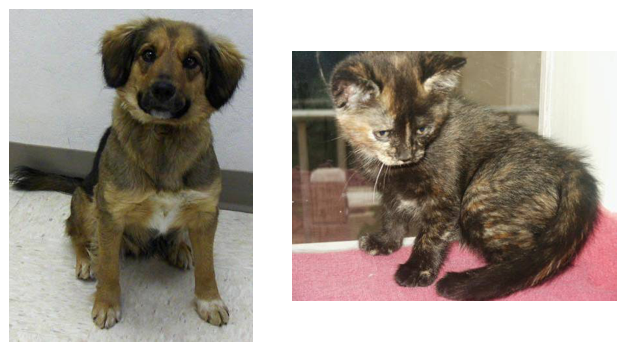

Nous emploierons ce jeu de données pour entraîner un réseau de neurones capable de **distinguer les chats des chiens**.  
Aujourd’hui, cela peut sembler banal, mais il y a encore quelques années, c’était un véritable **défi pour les systèmes de vision par ordinateur**.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt

import torch
from torchvision import datasets, transforms

import helper


La façon la plus simple de charger des images est d’utiliser `datasets.ImageFolder` de la bibliothèque **torchvision** ([documentation](http://pytorch.org/docs/master/torchvision/datasets.html#imagefolder)).  
En général, vous utiliserez `ImageFolder` comme ceci :

```python
dataset = datasets.ImageFolder('path/to/data', transform=transform)
````

où `'path/to/data'` est le chemin d’accès au répertoire contenant les données, et `transform` est une **séquence d’opérations de prétraitement** définies à l’aide du module [`transforms`](http://pytorch.org/docs/master/torchvision/transforms.html) de `torchvision`.

`ImageFolder` s’attend à une structure de répertoires comme celle-ci :

```
root/dog/xxx.png
root/dog/xxy.png
root/dog/xxz.png

root/cat/123.png
root/cat/nsdf3.png
root/cat/asd932_.png
```

Chaque classe (ici `cat` et `dog`) possède son **propre dossier** contenant les images correspondantes.
Les images sont alors automatiquement **étiquetées** d’après le nom du dossier.
Ainsi, l’image `123.png` sera chargée avec l’étiquette `cat`.

Vous pouvez télécharger le jeu de données déjà structuré de cette manière [ici](https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip).
Il est déjà séparé en **jeu d’entraînement** et **jeu de test**.

---

### 🔄 Transformations

Lors du chargement des données avec `ImageFolder`, il faut définir des **transformations (transforms)**.
Par exemple, les images ont des tailles différentes, mais le modèle nécessite qu’elles aient toutes la même taille pour l’entraînement.
On peut donc :

* les **redimensionner** avec `transforms.Resize()`, ou
* les **rogner** avec `transforms.CenterCrop()` ou `transforms.RandomResizedCrop()`.

Il faut également **convertir les images en tenseurs PyTorch** à l’aide de `transforms.ToTensor()`.

En général, ces étapes sont combinées en un pipeline à l’aide de `transforms.Compose()`, qui exécute une liste de transformations dans l’ordre.
Par exemple, pour redimensionner, recadrer, puis convertir en tenseur :

```python
transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])
```

Il existe de nombreuses autres transformations possibles — consultez la [documentation](http://pytorch.org/docs/master/torchvision/transforms.html) pour plus de détails.

---

### 📦 Data Loaders

Une fois le `ImageFolder` chargé, il faut le passer à un [`DataLoader`](http://pytorch.org/docs/master/data.html#torch.utils.data.DataLoader).
Le **DataLoader** prend un dataset (par exemple celui renvoyé par `ImageFolder`) et retourne des **lots (batches)** d’images et leurs **étiquettes** correspondantes.
Vous pouvez régler plusieurs paramètres, comme :

* la **taille des lots (`batch_size`)**,
* et le **mélange des données (`shuffle`)** à chaque époque.

Exemple :

```python
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
```

L’objet `dataloader` est un **générateur**.
Pour extraire des données, on peut soit boucler dessus, soit le convertir en itérateur et appeler `next()` :

```python
# Boucle pour récupérer un batch à chaque itération
for images, labels in dataloader:
    pass

# Obtenir un seul batch
images, labels = next(iter(dataloader))
```

---

> **Exercice :**
> Chargez les images depuis le dossier `Cat_Dog_data/train`,
> définissez quelques transformations,
> puis construisez le **DataLoader**.



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/DeepLearning/Devoir de DeepLearning

/content/drive/MyDrive/DeepLearning/Devoir de DeepLearning


In [4]:
%ls

best_model_scratch.pt   Cat_Dog_data/     CNN-catsdogs-Mariama_Diouf.ipynb
best_model_transfer.pt  Cat_Dog_data.zip  __MACOSX/


In [5]:
#extract Cat_Dog_data.zip
#!unzip Cat_Dog_data.zip

In [6]:
!unzip -o -q Cat_Dog_data.zip -d .

In [7]:
data_dir = 'Cat_Dog_data/train'

#transform = # TODO: compose transforms here
transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

#dataset = # TODO: create the ImageFolder
dataset = datasets.ImageFolder(data_dir, transform=transform)

#dataloader = # TODO: use the ImageFolder dataset to create the DataLoader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def imshow(image, ax=None, title=None, normalize=True):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()

    image = image.numpy().transpose((1, 2, 0))

    if normalize:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.set_xticklabels('')
    ax.set_yticklabels('')

    return ax

<Axes: >

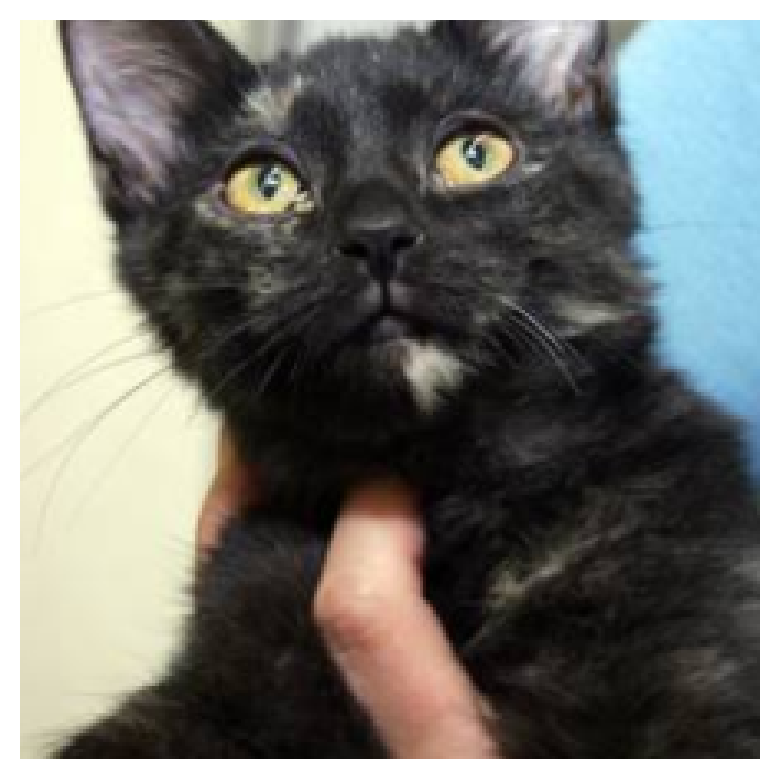

In [9]:
# Run this to test your data loader
images, labels = next(iter(dataloader))
imshow(images[0], normalize=False)

Si vous avez correctement chargé les données, vous devriez obtenir un affichage similaire à celui-ci (votre image sera différente) :




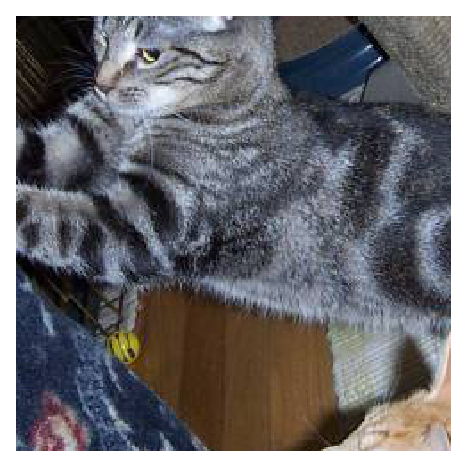


## Augmentation de Données

Une stratégie courante pour entraîner des réseaux de neurones consiste à introduire une **certaine forme d’aléatoire dans les données d’entrée**.  
Par exemple, on peut faire tourner, refléter, redimensionner et/ou rogner aléatoirement les images pendant l’entraînement.  
Cela aide le réseau à **mieux généraliser**, car il voit les mêmes images sous différentes formes : positions, tailles, orientations, etc.

Pour appliquer une rotation, un recadrage et un redimensionnement aléatoires, puis retourner les images horizontalement, on peut définir les transformations ainsi :

```python
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])
````

Il est également recommandé de **normaliser les images** à l’aide de `transforms.Normalize`.
Cette transformation prend en entrée :

* une liste de **moyennes** (`mean`)
* et une liste d’**écarts-types** (`std`)

Chaque canal de couleur est alors normalisé selon la formule :

```
input[channel] = (input[channel] - mean[channel]) / std[channel]
```

Soustraire la moyenne recentre les données autour de zéro,
et diviser par l’écart-type comprime les valeurs entre **-1 et 1**.
Cette normalisation aide à maintenir les **poids du réseau proches de zéro**,
rendant ainsi la **rétropropagation plus stable**.
Sans normalisation, le réseau risque souvent d’échouer à apprendre correctement.

Vous pouvez consulter la **liste complète des transformations disponibles** [ici](http://pytorch.org/docs/0.3.0/torchvision/transforms.html).

Lors des phases de **validation** ou de **test**, on utilise généralement des images **non altérées** (hormis la normalisation).
Ainsi, pour les données de validation ou de test, on se contente en général de **redimensionner** et **recadrer** les images.

---

> **Exercice :**
> Définissez ci-dessous les **transformations** pour les données d’entraînement et de test.
> Ne mettez pas encore la normalisation.

```



In [10]:
data_dir = 'Cat_Dog_data'

# TODO: Define transforms for the training data and testing data
train_transforms = transforms.Compose([
    #transforms.CenterCrop(30),
    #transforms.AutoAugment(),
    transforms.Resize(224),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transforms =transforms.Compose([
    #transforms.CenterCrop(10),
    transforms.Resize(224),
    transforms.ToTensor()
])


# Pass transforms in here, then run the next cell to see how the transforms look
train_data = datasets.ImageFolder(data_dir + '/train', transform=train_transforms)
test_data = datasets.ImageFolder(data_dir + '/test', transform=test_transforms)

trainloader = torch.utils.data.DataLoader(train_data, batch_size=32)
testloader = torch.utils.data.DataLoader(test_data, batch_size=32)

In [11]:
# change this to the trainloader or testloader
data_iter = iter(trainloader)

In [12]:
images, labels = next(data_iter)
labels

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])

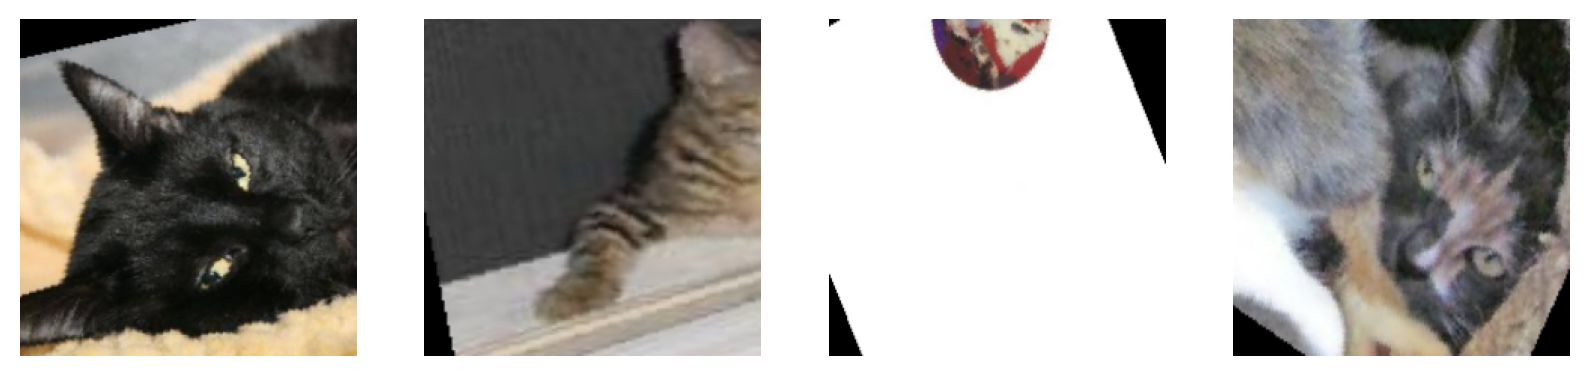

In [13]:


images, labels = next(data_iter)
fig, axes = plt.subplots(figsize=(10,4), ncols=4)
for ii in range(4):
    ax = axes[ii]
    imshow(images[ii], ax=ax, normalize=False)

Vos images transformées devraient ressembler à quelque chose comme ceci.




<center>Training examples:</center>


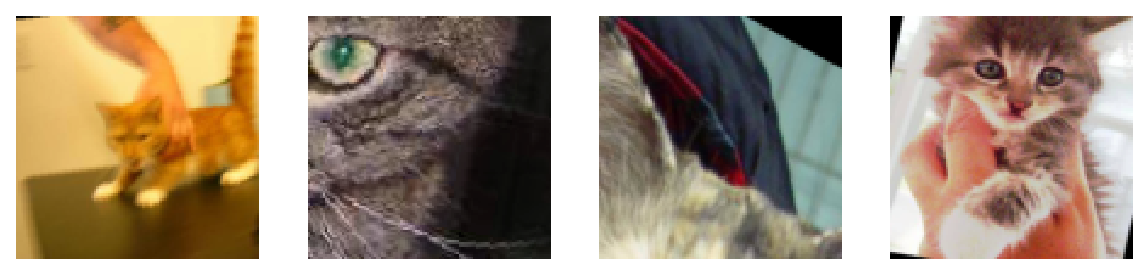

<center>Testing examples:</center>

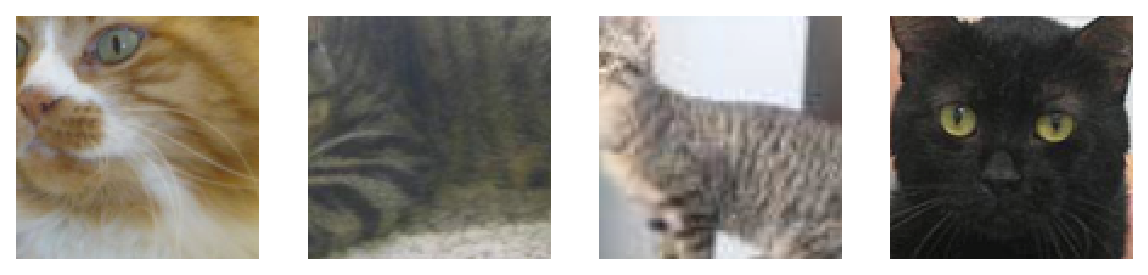


À ce stade, vous devriez être en mesure de charger les données pour l’entraînement et le test.  
Vous pouvez maintenant essayer de construire un réseau capable de **classer les chats et les chiens**.



# DEVOIR – CNN “from scratch” vs Transfert Learning (Cats vs Dogs)

## Objectif

Comparer **un modèle CNN entraîné from scratch** et **un modèle en transfert d’apprentissage** sur le même jeu de données (cats vs dogs). Montrer l’impact du transfert learning sur la convergence, la performance et la robustesse.

## Ce qui est **obligatoire**

1. **Deux expériences distinctes**

   * Expérience A : CNN **from scratch** (architecture simple minimum 3 bloc avec conv).
   * Expérience B : **Transfert learning** (ex. ResNet, MobileNet, EfficientNet…), couches finales adaptées.
2. **Bonnes pratiques de régularisation**

   * Utiliser **Dropout** ET **Batch Normalization** (justifier où et pourquoi).
3. **Suivi des métriques**

   * **Training loss**, **Accuracy**, **Précision**, **Recall** à chaque époque (et idéalement sur train/val si vous faites une validation).
   * Tracer des **courbes** et **comparer** les deux approches.
4. **Optimisation**

   * Tester au moins **2 optimiseurs** (ex. SGD et Adam).
   * Chercher un **bon learning rate** (essais ou scheduler).
5. **GPU**

   * Entraîner **sur GPU** si disponible (vérification et mention dans README).
6. **Persistance du modèle**

   * **Sauvegarder** le meilleur modèle (.pt/.pth) localement (ne **pas** pousser dans GitHub).
   * **Recharger** le modèle pour faire le **test final** et rapporter les métriques.
7. **Reproductibilité**

   * Fixer un **seed**

## Ce qui est **souhaité (bonus)**

* **Split train/validation** (clair et justifié).
* **Data augmentation** raisonnable.
* **Scheduler** (ex. StepLR, CosineAnnealingLR).
* **Matrice de confusion** et quelques **erreurs typiques** commentées.
* Journalisation (TensorBoard/W&B) — sans pousser les fichiers lourds.

## Données

* Utilisez le même corpus **Cats vs Dogs** que vu en cours (ou équivalent).
* Ne **poussez pas** les données sur GitHub. Indiquez seulement **comment** les télécharger/placer.

## Structure du dépôt GitHub (exemple)

```
cnn-catsdogs-<NomPrenom>/
├─ notebook.ipynb
├─ .gitignore
├─ requirements.txt (ou environment.yml)
├─ README.md
└─ LICENSE (optionnel)
```

### `.gitignore` (minimum)

```
data/
*.pt
*.pth
runs/
checkpoints/
```

## Contenu attendu du **README.md**

* **Titre & objectif** du projet.
* **Environnement** ( `pip install -r requirements.txt` ou `conda env create -f environment.yml`).
* **Organisation des données** (où télécharger, où placer les dossiers).
* **Commandes pour entraîner** :

  * From scratch : arguments clés (batch size, lr, epochs, optimiser, dropout, BN, scheduler…).
  * Transfert learning : même chose + quelle base (gel des couches ou fine-tuning).
* **Commandes pour évaluer / recharger le modèle** (chemin du checkpoint local).
* **Résultats** : tableaux + courbes (loss/accuracy/précision/recall) pour les deux expériences, **comparaison et analyse** (2–3 paragraphes).
* **Limites & pistes d’amélioration** (brèves).

## Évaluation (grille indicative)

* Rigueur expérimentale & métriques (30 %)
* Qualité des modèles & optimisation (25 %)
* Clarté du code & structure du dépôt (20 %)
* README (reproductibilité, analyse, figures) (20 %)
* Bonus (val split, augmentation, scheduler, confusion matrix) (5 %)

## Remise
* ** FAIRE une vidéo de 05 à 10 minute pour expliquer votre travail"
* Envoyez **le lien du dépôt** à **[diallomous@gmail.com](mailto:diallomous@gmail.com)**
* **Date limite : Vendredi 25 Septembre  avant 23h00. (Africa/Dakar).**

> Rappel :  Assurez-vous que votre dépôt permet de **reproduire** les expériences via les instructions du README.


---
#  Travail personnel — début de ma solution

* À partir d'ici commence mon propre travail : setup, chargement des données avec split train/val, modèles, entraînement, comparaison et résultats.)*
---

**Sommaire de ma solution**
1. Setup (seed, device, imports)
2. Chargement des données + transforms + split train/val
3. Modèle A — CNN from scratch
4. Modèle B — Transfer Learning (ResNet18)
5. Fonctions d'entraînement / évaluation (loss, accuracy, precision, recall)
6. Expérience A : entraînement CNN from scratch (SGD vs Adam)
7. Expérience B : entraînement Transfer Learning (SGD vs Adam)
8. Comparaison des courbes (les deux expériences)
9. Matrice de confusion (bonus)
10. Sauvegarde / rechargement du meilleur modèle + test final


## 1. Setup — imports, seed, device

On fixe une **seed** partout (Python, NumPy, PyTorch) pour la reproductibilité, et on détecte le GPU si disponible.

In [14]:
!pip install torchvision scikit-learn matplotlib --quiet


In [15]:
import os
import time
import random
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# ---- Reproductibilité ----
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ---- GPU / CPU ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)
if device.type == "cuda":
    print("GPU :", torch.cuda.get_device_name(0))


Device utilisé : cuda
GPU : Tesla T4


## 2. Chargement des données

On réutilise le jeu **Cat_Dog_data** (structure `train/cat`, `train/dog`, `test/cat`, `test/dog`).


In [16]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/DeepLearning/Devoir de DeepLearning


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/DeepLearning/Devoir de DeepLearning


In [17]:
DATA_DIR = "Cat_Dog_data"
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_SPLIT = 0.2

# Transforms
# Entraînement : augmentation raisonnable (rotation, crop, flip)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225]),
])

# Validation / Test : pas d'augmentation, juste resize + crop + normalisation
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225]),
])


In [18]:
# Datasets
full_train_data = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transforms)
test_data = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=eval_transforms)

class_names = full_train_data.classes
print("Classes détectées :", class_names)

# Split train / validation
n_val = int(len(full_train_data) * VAL_SPLIT)
n_train = len(full_train_data) - n_val

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(full_train_data, [n_train, n_val], generator=generator)


val_base = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=eval_transforms)
val_subset.dataset = val_base

print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_data)}")

trainloader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valloader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
testloader  = DataLoader(test_data,    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


Classes détectées : ['cat', 'dog']
Train: 18000 | Val: 4500 | Test: 2500


### Vérification visuelle d'un batch

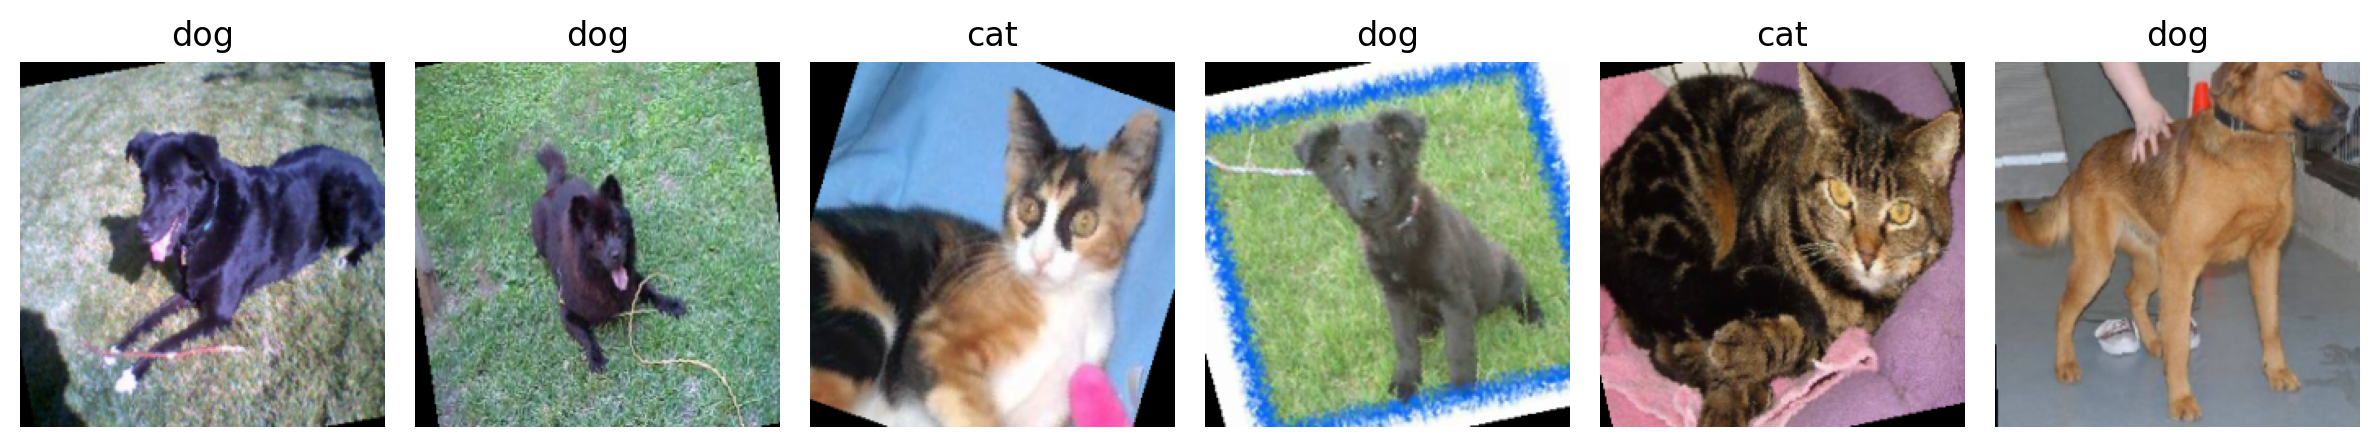

In [19]:
def imshow(image, ax=None, title=None):
    """Affiche un tenseur normalisé (dé-normalise pour affichage)."""
    if ax is None:
        fig, ax = plt.subplots()
    image = image.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    image = np.clip(image, 0, 1)
    ax.imshow(image)
    ax.axis("off")
    if title is not None:
        ax.set_title(title)
    return ax

images, labels = next(iter(trainloader))
fig, axes = plt.subplots(figsize=(12, 4), ncols=6)
for i in range(6):
    imshow(images[i], ax=axes[i], title=class_names[labels[i]])
plt.tight_layout()
plt.show()


## 3. Modèle A — CNN "from scratch"

Architecture simple à **3 blocs convolutionnels** (Conv → BatchNorm → ReLU → MaxPool),
suivie d'un classifieur dense avec **Dropout**.

- **BatchNorm** juste après chaque convolution : stabilise et accélère l'entraînement en
  normalisant les activations, ce qui limite le *covariate shift* interne.
- **Dropout** dans le classifieur dense : désactive aléatoirement des neurones pendant
  l'entraînement pour réduire le surapprentissage (le réseau ne peut pas trop dépendre
  d'un petit groupe de neurones).


In [20]:
class CNNFromScratch(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 224 -> 112

            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 112 -> 56

            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 56 -> 28

            # Bloc 4 (bonus, aide la convergence)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((7, 7)),  # taille fixe quelle que soit l'entrée
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256 * 7 * 7, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_a_test = CNNFromScratch()
n_params = sum(p.numel() for p in model_a_test.parameters())
print(f"CNNFromScratch : {n_params:,} paramètres")
del model_a_test


CNNFromScratch : 3,601,410 paramètres


## 4. Modèle B — Transfer Learning (ResNet18)

On part d'un **ResNet18 pré-entraîné sur ImageNet** :
- On gèle les couches convolutionnelles

- On **remplace la dernière couche** (`fc`) par un petit classifieur adapté à nos 2 classes,

- BatchNorm est déjà présent dans ResNet18 (hérité du modèle pré-entraîné).


In [21]:
def build_transfer_model(num_classes=2, dropout=0.4, freeze_backbone=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes),
    )
    return model

model_b_test = build_transfer_model()
trainable = sum(p.numel() for p in model_b_test.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_b_test.parameters())
print(f"ResNet18 transfer : {trainable:,} paramètres entraînables / {total:,} au total")
del model_b_test


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 45.2MB/s]


ResNet18 transfer : 1,026 paramètres entraînables / 11,177,538 au total


## 5. Fonctions d'entraînement / évaluation

On suit à chaque époque : **loss**, **accuracy**, **precision**, **recall** (sur train ET val).


In [22]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Une passe complète sur `loader`. Si `optimizer` est fourni -> mode entraînement."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_preds, all_labels = [], []

    torch.set_grad_enabled(is_train)
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_prec = precision_score(all_labels, all_preds, zero_division=0)
    epoch_rec = recall_score(all_labels, all_preds, zero_division=0)

    return epoch_loss, epoch_acc, epoch_prec, epoch_rec


def train_model(model, trainloader, valloader, optimizer, scheduler=None,
                 epochs=10, model_name="model"):
    """Boucle d'entraînement complète, garde le meilleur modèle (meilleure val_acc)."""
    criterion = nn.CrossEntropyLoss()
    model.to(device)

    history = {
        "train_loss": [], "train_acc": [], "train_prec": [], "train_rec": [],
        "val_loss": [], "val_acc": [], "val_prec": [], "val_rec": [],
    }

    best_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc, tr_prec, tr_rec = run_epoch(model, trainloader, criterion, optimizer)
        val_loss, val_acc, val_prec, val_rec = run_epoch(model, valloader, criterion, optimizer=None)

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["train_prec"].append(tr_prec); history["train_rec"].append(tr_rec)
        history["val_loss"].append(val_loss);  history["val_acc"].append(val_acc)
        history["val_prec"].append(val_prec);  history["val_rec"].append(val_rec)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        dt = time.time() - t0
        print(f"[{model_name}] Epoch {epoch}/{epochs} ({dt:.1f}s) | "
              f"train_loss={tr_loss:.4f} acc={tr_acc:.3f} prec={tr_prec:.3f} rec={tr_rec:.3f} || "
              f"val_loss={val_loss:.4f} acc={val_acc:.3f} prec={val_prec:.3f} rec={val_rec:.3f}")

    model.load_state_dict(best_state)
    return model, history, best_acc


## 6. Expérience A — CNN from scratch

On teste **2 optimiseurs** (SGD et Adam) avec le même nombre d'époques, puis on garde
la meilleure configuration pour la suite.


In [23]:
EPOCHS_A = 10
LR_SGD = 0.01
LR_ADAM = 1e-3

# Run 1 : SGD
set_seed(SEED)
model_a_sgd = CNNFromScratch().to(device)
optimizer_sgd = optim.SGD(model_a_sgd.parameters(), lr=LR_SGD, momentum=0.9)
scheduler_sgd = optim.lr_scheduler.StepLR(optimizer_sgd, step_size=5, gamma=0.5)

model_a_sgd, hist_a_sgd, best_acc_a_sgd = train_model(
    model_a_sgd, trainloader, valloader, optimizer_sgd, scheduler_sgd,
    epochs=EPOCHS_A, model_name="CNN-scratch-SGD"
)


[CNN-scratch-SGD] Epoch 1/10 (181.1s) | train_loss=0.6351 acc=0.635 prec=0.659 rec=0.561 || val_loss=0.5991 acc=0.668 prec=0.628 rec=0.823
[CNN-scratch-SGD] Epoch 2/10 (180.5s) | train_loss=0.6024 acc=0.662 prec=0.687 rec=0.595 || val_loss=0.5984 acc=0.698 prec=0.658 rec=0.826
[CNN-scratch-SGD] Epoch 3/10 (180.1s) | train_loss=0.5727 acc=0.701 prec=0.691 rec=0.728 || val_loss=0.5633 acc=0.724 prec=0.832 rec=0.564
[CNN-scratch-SGD] Epoch 4/10 (188.4s) | train_loss=0.5427 acc=0.720 prec=0.714 rec=0.734 || val_loss=0.4885 acc=0.756 prec=0.699 rec=0.902
[CNN-scratch-SGD] Epoch 5/10 (176.9s) | train_loss=0.5255 acc=0.738 prec=0.712 rec=0.799 || val_loss=0.5182 acc=0.786 prec=0.852 rec=0.693
[CNN-scratch-SGD] Epoch 6/10 (177.6s) | train_loss=0.4646 acc=0.775 prec=0.738 rec=0.851 || val_loss=0.4058 acc=0.819 prec=0.804 rec=0.844
[CNN-scratch-SGD] Epoch 7/10 (176.0s) | train_loss=0.4428 acc=0.790 prec=0.768 rec=0.830 || val_loss=0.4176 acc=0.820 prec=0.782 rec=0.888
[CNN-scratch-SGD] Epoch 8/1

In [24]:
# Run 2 : Adam
set_seed(SEED)
model_a_adam = CNNFromScratch().to(device)
optimizer_adam = optim.Adam(model_a_adam.parameters(), lr=LR_ADAM)
scheduler_adam = optim.lr_scheduler.CosineAnnealingLR(optimizer_adam, T_max=EPOCHS_A)

model_a_adam, hist_a_adam, best_acc_a_adam = train_model(
    model_a_adam, trainloader, valloader, optimizer_adam, scheduler_adam,
    epochs=EPOCHS_A, model_name="CNN-scratch-Adam"
)


[CNN-scratch-Adam] Epoch 1/10 (174.0s) | train_loss=0.6100 acc=0.677 prec=0.698 rec=0.624 || val_loss=0.5089 acc=0.753 prec=0.790 rec=0.691
[CNN-scratch-Adam] Epoch 2/10 (165.8s) | train_loss=0.5231 acc=0.743 prec=0.762 rec=0.706 || val_loss=0.4596 acc=0.786 prec=0.753 rec=0.851
[CNN-scratch-Adam] Epoch 3/10 (170.7s) | train_loss=0.4679 acc=0.784 prec=0.792 rec=0.770 || val_loss=0.4894 acc=0.777 prec=0.881 rec=0.642
[CNN-scratch-Adam] Epoch 4/10 (181.1s) | train_loss=0.4275 acc=0.807 prec=0.813 rec=0.797 || val_loss=0.4187 acc=0.806 prec=0.885 rec=0.703
[CNN-scratch-Adam] Epoch 5/10 (172.0s) | train_loss=0.3957 acc=0.828 prec=0.827 rec=0.827 || val_loss=0.4493 acc=0.790 prec=0.928 rec=0.629
[CNN-scratch-Adam] Epoch 6/10 (176.5s) | train_loss=0.3670 acc=0.846 prec=0.849 rec=0.842 || val_loss=0.3323 acc=0.859 prec=0.867 rec=0.848
[CNN-scratch-Adam] Epoch 7/10 (180.9s) | train_loss=0.3347 acc=0.860 prec=0.863 rec=0.856 || val_loss=0.3656 acc=0.845 prec=0.786 rec=0.949
[CNN-scratch-Adam] E

In [25]:
# On retient le meilleur des deux runs pour l'expérience A
if best_acc_a_adam >= best_acc_a_sgd:
    model_a, hist_a, best_acc_a = model_a_adam, hist_a_adam, best_acc_a_adam
    optimizer_a_name = "Adam"
else:
    model_a, hist_a, best_acc_a = model_a_sgd, hist_a_sgd, best_acc_a_sgd
    optimizer_a_name = "SGD"

print(f"Meilleur optimiseur pour l'Expérience A (from scratch) : {optimizer_a_name} "
      f"(val_acc={best_acc_a:.3f})")

torch.save(model_a.state_dict(), "best_model_scratch.pt")


Meilleur optimiseur pour l'Expérience A (from scratch) : Adam (val_acc=0.892)


## 7. Expérience B — Transfer Learning (ResNet18)

Même démarche : comparaison **SGD vs Adam**, mais uniquement sur les paramètres
entraînables (le classifieur final, puisque le backbone est gelé).


In [26]:
EPOCHS_B = 8
LR_SGD_B = 0.01
LR_ADAM_B = 1e-3

# Run 1 : SGD
set_seed(SEED)
model_b_sgd = build_transfer_model(freeze_backbone=True).to(device)
optimizer_b_sgd = optim.SGD(filter(lambda p: p.requires_grad, model_b_sgd.parameters()),
                             lr=LR_SGD_B, momentum=0.9)
scheduler_b_sgd = optim.lr_scheduler.StepLR(optimizer_b_sgd, step_size=4, gamma=0.5)

model_b_sgd, hist_b_sgd, best_acc_b_sgd = train_model(
    model_b_sgd, trainloader, valloader, optimizer_b_sgd, scheduler_b_sgd,
    epochs=EPOCHS_B, model_name="ResNet18-transfer-SGD"
)


[ResNet18-transfer-SGD] Epoch 1/8 (174.2s) | train_loss=0.3528 acc=0.918 prec=0.919 rec=0.916 || val_loss=0.0921 acc=0.975 prec=0.974 rec=0.976
[ResNet18-transfer-SGD] Epoch 2/8 (172.5s) | train_loss=0.2973 acc=0.934 prec=0.934 rec=0.934 || val_loss=0.0702 acc=0.978 prec=0.980 rec=0.976
[ResNet18-transfer-SGD] Epoch 3/8 (177.2s) | train_loss=0.3196 acc=0.926 prec=0.926 rec=0.926 || val_loss=0.0753 acc=0.976 prec=0.979 rec=0.972
[ResNet18-transfer-SGD] Epoch 4/8 (171.8s) | train_loss=0.3408 acc=0.928 prec=0.928 rec=0.928 || val_loss=0.0917 acc=0.971 prec=0.958 rec=0.986
[ResNet18-transfer-SGD] Epoch 5/8 (169.2s) | train_loss=0.2696 acc=0.934 prec=0.934 rec=0.934 || val_loss=0.0673 acc=0.976 prec=0.971 rec=0.981
[ResNet18-transfer-SGD] Epoch 6/8 (171.5s) | train_loss=0.2245 acc=0.935 prec=0.936 rec=0.934 || val_loss=0.0871 acc=0.971 prec=0.992 rec=0.949
[ResNet18-transfer-SGD] Epoch 7/8 (173.4s) | train_loss=0.2216 acc=0.933 prec=0.936 rec=0.930 || val_loss=0.0676 acc=0.974 prec=0.961 re

In [27]:
# Run 2 : Adam
set_seed(SEED)
model_b_adam = build_transfer_model(freeze_backbone=True).to(device)
optimizer_b_adam = optim.Adam(filter(lambda p: p.requires_grad, model_b_adam.parameters()),
                               lr=LR_ADAM_B)
scheduler_b_adam = optim.lr_scheduler.CosineAnnealingLR(optimizer_b_adam, T_max=EPOCHS_B)

model_b_adam, hist_b_adam, best_acc_b_adam = train_model(
    model_b_adam, trainloader, valloader, optimizer_b_adam, scheduler_b_adam,
    epochs=EPOCHS_B, model_name="ResNet18-transfer-Adam"
)


[ResNet18-transfer-Adam] Epoch 1/8 (184.3s) | train_loss=0.1935 acc=0.917 prec=0.918 rec=0.915 || val_loss=0.0688 acc=0.975 prec=0.982 rec=0.967
[ResNet18-transfer-Adam] Epoch 2/8 (170.0s) | train_loss=0.1363 acc=0.945 prec=0.947 rec=0.943 || val_loss=0.0650 acc=0.975 prec=0.961 rec=0.991
[ResNet18-transfer-Adam] Epoch 3/8 (170.3s) | train_loss=0.1402 acc=0.943 prec=0.942 rec=0.944 || val_loss=0.0608 acc=0.976 prec=0.970 rec=0.983
[ResNet18-transfer-Adam] Epoch 4/8 (168.6s) | train_loss=0.1375 acc=0.945 prec=0.946 rec=0.943 || val_loss=0.0647 acc=0.977 prec=0.989 rec=0.965
[ResNet18-transfer-Adam] Epoch 5/8 (167.3s) | train_loss=0.1405 acc=0.944 prec=0.946 rec=0.942 || val_loss=0.0569 acc=0.979 prec=0.977 rec=0.981
[ResNet18-transfer-Adam] Epoch 6/8 (165.5s) | train_loss=0.1321 acc=0.948 prec=0.949 rec=0.948 || val_loss=0.0587 acc=0.977 prec=0.973 rec=0.982
[ResNet18-transfer-Adam] Epoch 7/8 (166.6s) | train_loss=0.1282 acc=0.949 prec=0.949 rec=0.948 || val_loss=0.0595 acc=0.979 prec=0

In [28]:
#On retient le meilleur des deux runs pour l'expérience B
if best_acc_b_adam >= best_acc_b_sgd:
    model_b, hist_b, best_acc_b = model_b_adam, hist_b_adam, best_acc_b_adam
    optimizer_b_name = "Adam"
else:
    model_b, hist_b, best_acc_b = model_b_sgd, hist_b_sgd, best_acc_b_sgd
    optimizer_b_name = "SGD"

print(f"Meilleur optimiseur pour l'Expérience B (transfer learning) : {optimizer_b_name} "
      f"(val_acc={best_acc_b:.3f})")

torch.save(model_b.state_dict(), "best_model_transfer.pt")


Meilleur optimiseur pour l'Expérience B (transfer learning) : Adam (val_acc=0.980)


## 8. Comparaison des deux expériences (courbes)

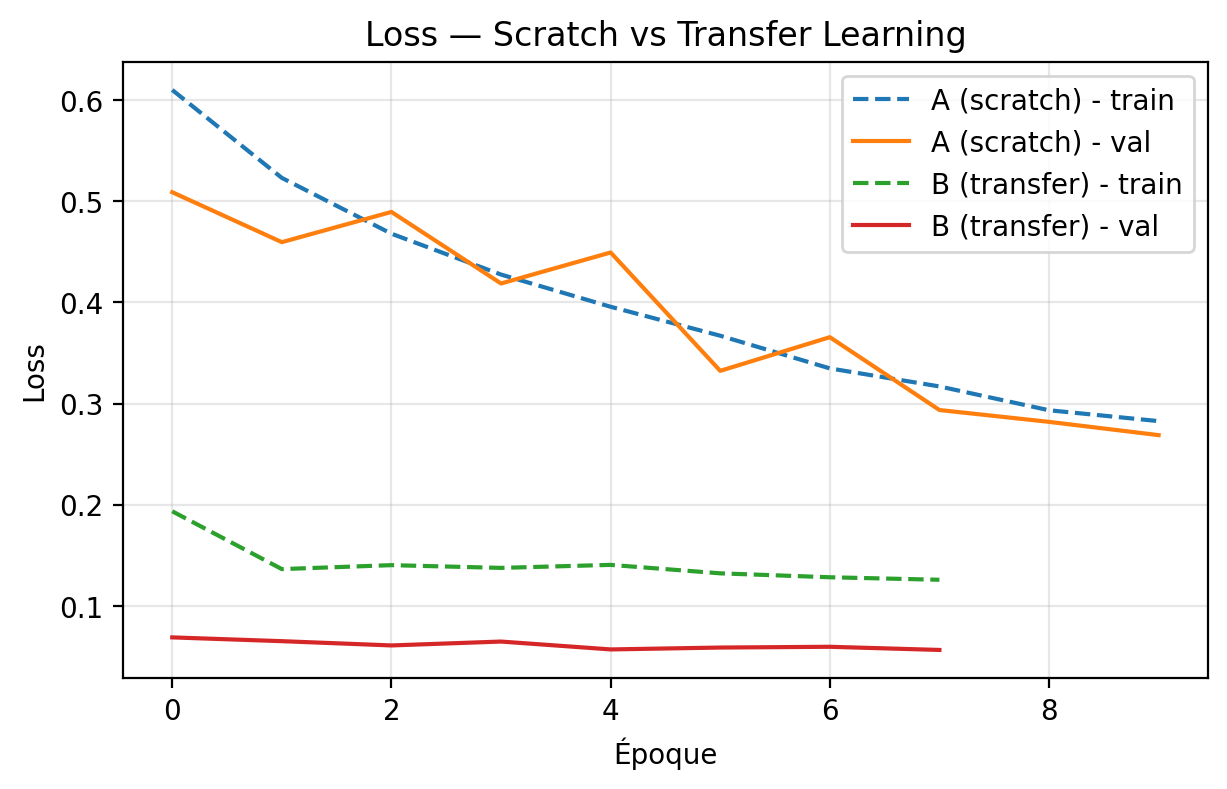

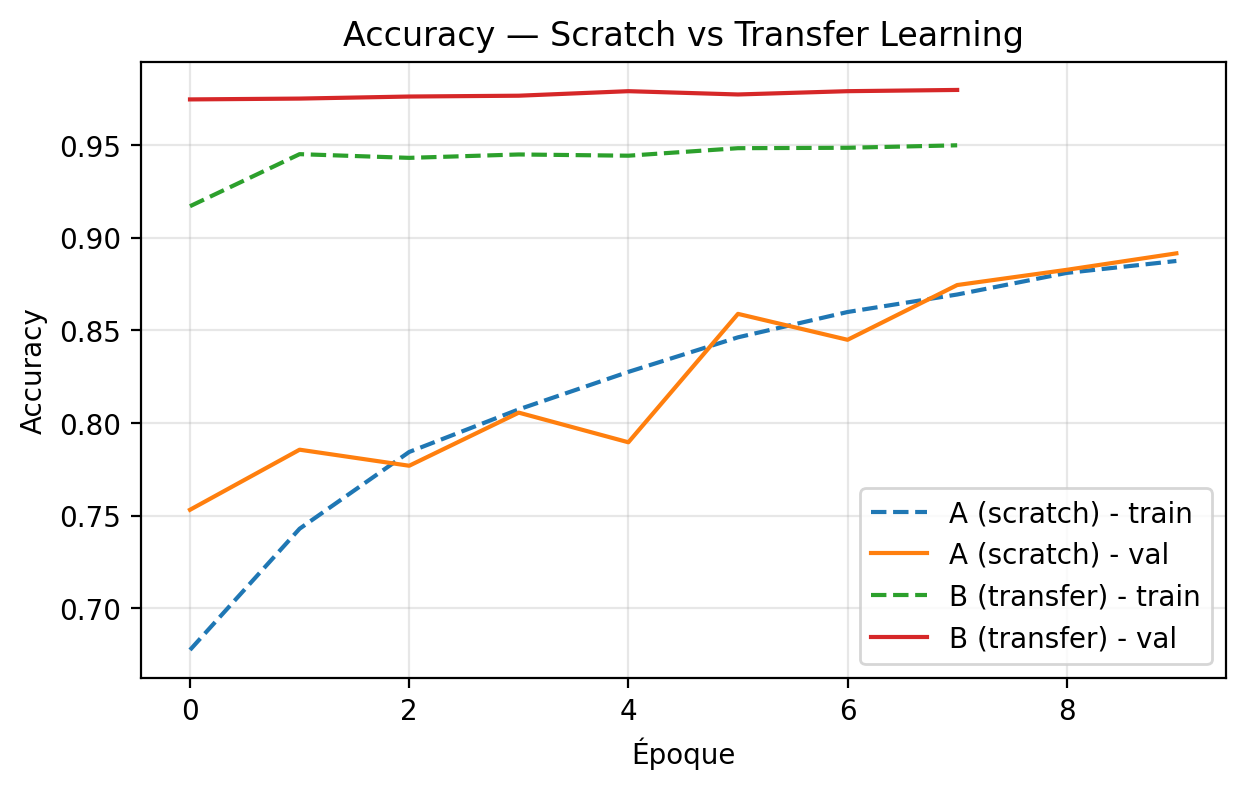

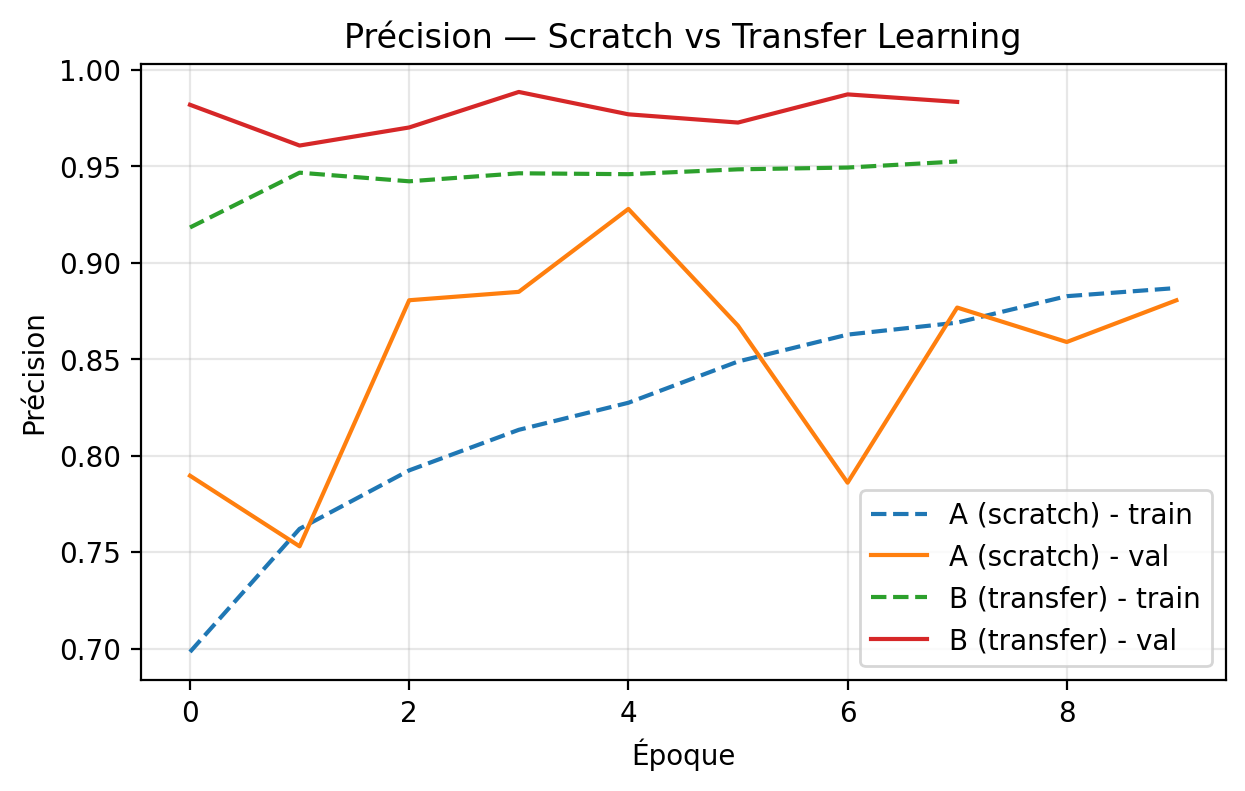

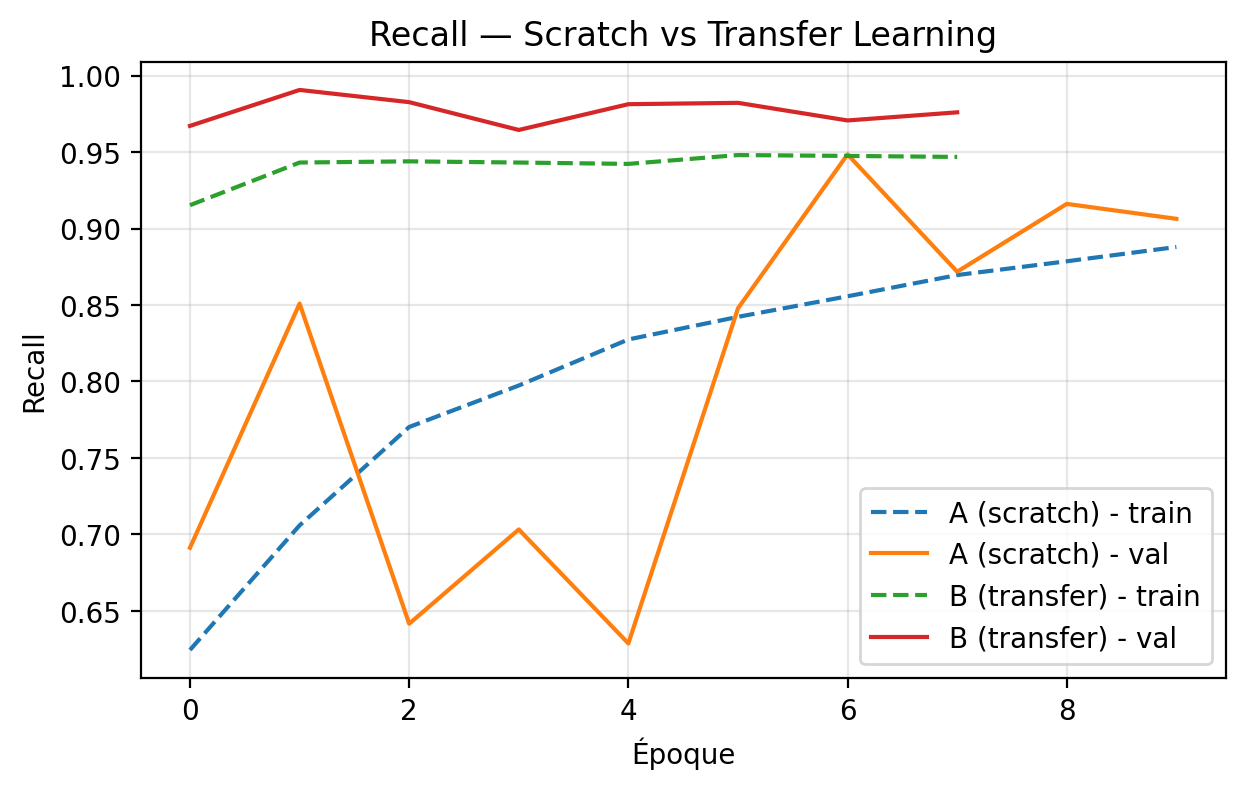

In [29]:
def plot_comparison(hist_a, hist_b, metric, ylabel):
    plt.figure(figsize=(7, 4))
    plt.plot(hist_a[f"train_{metric}"], label="A (scratch) - train", linestyle="--")
    plt.plot(hist_a[f"val_{metric}"],   label="A (scratch) - val")
    plt.plot(hist_b[f"train_{metric}"], label="B (transfer) - train", linestyle="--")
    plt.plot(hist_b[f"val_{metric}"],   label="B (transfer) - val")
    plt.xlabel("Époque")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} — Scratch vs Transfer Learning")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_comparison(hist_a, hist_b, "loss", "Loss")
plot_comparison(hist_a, hist_b, "acc", "Accuracy")
plot_comparison(hist_a, hist_b, "prec", "Précision")
plot_comparison(hist_a, hist_b, "rec", "Recall")


## 9. Matrice de confusion (bonus)

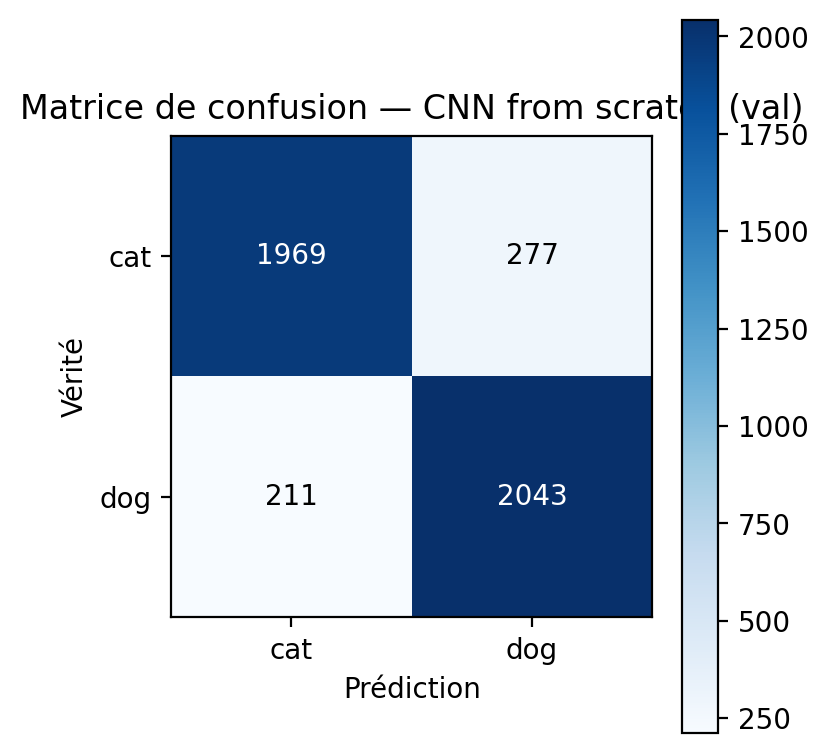

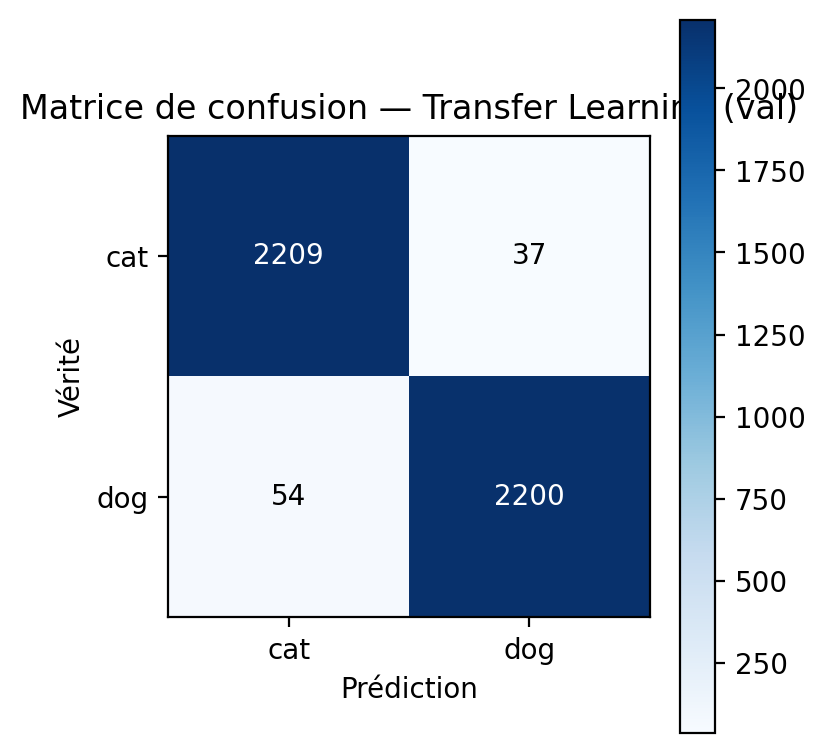

In [30]:
def get_all_preds(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


def plot_confusion(model, loader, title):
    y_true, y_pred = get_all_preds(model, loader)
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names)
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
    ax.set_xlabel("Prédiction"); ax.set_ylabel("Vérité")
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()
    return cm

cm_a = plot_confusion(model_a, valloader, "Matrice de confusion — CNN from scratch (val)")
cm_b = plot_confusion(model_b, valloader, "Matrice de confusion — Transfer Learning (val)")


## 10. Rechargement du meilleur modèle + test final

On recharge les checkpoints sauvegardés (`best_model_scratch.pt`, `best_model_transfer.pt`)
et on évalue sur le **jeu de test**, jamais vu pendant l'entraînement.


In [31]:
criterion = nn.CrossEntropyLoss()

# Reload CNN from scratch
final_model_a = CNNFromScratch().to(device)
final_model_a.load_state_dict(torch.load("best_model_scratch.pt", map_location=device))

test_loss_a, test_acc_a, test_prec_a, test_rec_a = run_epoch(final_model_a, testloader, criterion)
print(f"[Test] CNN from scratch  -> loss={test_loss_a:.4f} acc={test_acc_a:.3f} "
      f"prec={test_prec_a:.3f} rec={test_rec_a:.3f}")

# Reload Transfer Learning
final_model_b = build_transfer_model(freeze_backbone=True).to(device)
final_model_b.load_state_dict(torch.load("best_model_transfer.pt", map_location=device))

test_loss_b, test_acc_b, test_prec_b, test_rec_b = run_epoch(final_model_b, testloader, criterion)
print(f"[Test] Transfer Learning -> loss={test_loss_b:.4f} acc={test_acc_b:.3f} "
      f"prec={test_prec_b:.3f} rec={test_rec_b:.3f}")


[Test] CNN from scratch  -> loss=0.2781 acc=0.875 prec=0.865 rec=0.890
[Test] Transfer Learning -> loss=0.0598 acc=0.976 prec=0.985 rec=0.967


In [32]:
# Tableau récapitulatif final
import pandas as pd

results = pd.DataFrame({
    "Modèle": ["CNN from scratch", "Transfer Learning (ResNet18)"],
    "Optimiseur retenu": [optimizer_a_name, optimizer_b_name],
    "Test Loss": [test_loss_a, test_loss_b],
    "Test Accuracy": [test_acc_a, test_acc_b],
    "Test Precision": [test_prec_a, test_prec_b],
    "Test Recall": [test_rec_a, test_rec_b],
})
results


,Modèle,Optimiseur retenu,Test Loss,Test Accuracy,Test Precision,Test Recall
0,CNN from scratch,Adam,0.278053,0.8752,0.864697,0.8896
1,Transfer Learning (ResNet18),Adam,0.059774,0.9760,0.984528,0.9672
